# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('House_Rent_Dataset.csv', sep=None, engine='python')
df.shape

(4746, 12)

In [3]:
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [5]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


In [6]:
stats = df[['BHK', 'Rent', 'Size', 'Bathroom']].describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [7]:
fig = px.histogram(
    df,
    x = 'Rent',
    nbins=100,
    title= 'Розподіл цільової змінної(Вартості оренди)'
)

fig.update_layout(
    showlegend= False,
    height = 400
)

fig.show()

In [8]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

In [9]:
total = len(df)
outliers_count = len(outliers)

percentage = outliers_count / total * 100
print(f"{percentage:.2f}%")

10.96%


Викиди становлять - 10.96 %. Маю припущення, що це вартість оренди люкс сегменту.

In [10]:
from enum import unique
cat_cols = df_clean.select_dtypes(include = ['object', 'category']).columns
df_clean[cat_cols].nunique()


,0
Posted On,80
Floor,340
Area Type,3
Area Locality,1997
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


In [44]:
df_clean

,BHK,Rent,Size,Bathroom,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing_Status_Furnished,Furnishing_Status_Semi-Furnished,Furnishing_Status_Unfurnished,Tenant_Preferred_Bachelors,Tenant_Preferred_Bachelors/Family,Tenant_Preferred_Family
0,2,10000,1100,2,False,False,False,False,True,False,False,False,True,False,True,False
1,2,20000,800,1,False,False,False,False,True,False,False,True,False,False,True,False
2,2,17000,1000,1,False,False,False,False,True,False,False,True,False,False,True,False
3,2,10000,800,1,False,False,False,False,True,False,False,False,True,False,True,False
4,2,7500,850,1,False,False,False,False,True,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,2,False,False,False,True,False,False,False,True,False,False,True,False
4742,3,29000,2000,3,False,False,False,True,False,False,False,True,False,False,True,False
4743,3,35000,1750,3,False,False,False,True,False,False,False,True,False,False,True,False
4744,3,45000,1500,2,False,False,False,True,False,False,False,True,False,False,False,True



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [12]:
metrics_df = df_clean[['BHK','Rent', 'Size', 'Bathroom']].dropna()

correlation_matrix = metrics_df.corr()

fig = px.imshow(
    correlation_matrix,
    text_auto= '.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками взаємодії',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [39]:
fig = px.scatter(
    x = df_clean['Size'],
    y = df_clean['Rent'],
    title = 'Кореляція між вартістю оренди та площею квартири',

)

fig.update_layout(height=500)
fig.show()

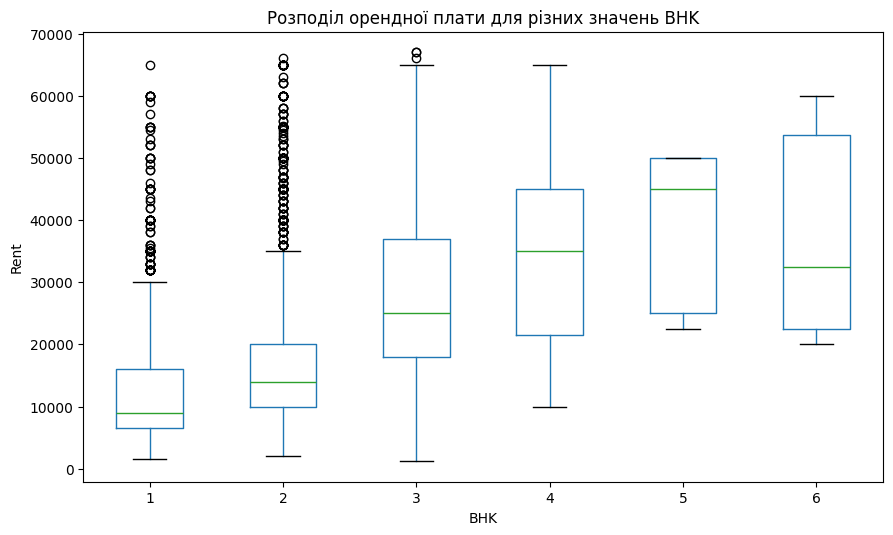

In [14]:
df_clean.boxplot(
    column = 'Rent',
    by = 'BHK',
    figsize=(10,6),
    grid = False
)

plt.title('Розподіл орендної плати для різних значень BHK')
plt.suptitle('')
plt.ylabel('Rent')
plt.show()

BHK - Кількість спалень, залів, кухонь.

Для 1 та 2 квартир розкид цін більш стабільний.
Для будинків з 3-6 кімнатами ми можемо помітити більш широкий спектр цін(більш широкий бокс).


Зі зростанням кількості кімнат медіанна вартість оренди зростає, але можемо помітити якусь аномалію в будинках з 6 кімнатами. Медіанна вартісь нижча за будинки з 5 кімнатами .

Для квартир 1-3 кімнати ми бачимо викиди в даних - це і є наші більш дорогі квартири, певно ліпший район, меблі, місто впливає на це.


Набільший рокзид цін нам оренду з 3 кімнатами, певно це відбувається через те, що на таку кількість кімнат найбільший попит, тому варіативність значень є дуже широка. Тут може міститись як квартиру дуже низького класу та і елітні.


## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [15]:
city_dummies = pd.get_dummies(df_clean['City'], prefix ='City')

In [16]:
city_dummies.head().astype(int)

,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0


In [17]:
FurnishingStatus_dummies = pd.get_dummies(df_clean['Furnishing Status'],prefix='Furnishing_Status')

In [18]:
FurnishingStatus_dummies.head().astype(int)

,Furnishing_Status_Furnished,Furnishing_Status_Semi-Furnished,Furnishing_Status_Unfurnished
0,0,0,1
1,0,1,0
2,0,1,0
3,0,0,1
4,0,0,1


In [19]:
TenantPreferred_dummies = pd.get_dummies(df_clean['Tenant Preferred'],prefix='Tenant_Preferred')

In [20]:
TenantPreferred_dummies.head().astype(int)

,Tenant_Preferred_Bachelors,Tenant_Preferred_Bachelors/Family,Tenant_Preferred_Family
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,1,0,0


In [21]:
df_clean = pd.concat([df_clean,city_dummies,FurnishingStatus_dummies,TenantPreferred_dummies], axis=1)

In [22]:
df_clean = df_clean.drop(columns=['City', 'Furnishing Status', 'Tenant Preferred','Posted On', 'Area Type',	'Area Locality',	'Point of Contact' ])

In [24]:
df_clean = df_clean.drop(columns=['Floor'])

In [25]:
df_clean

,BHK,Rent,Size,Bathroom,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing_Status_Furnished,Furnishing_Status_Semi-Furnished,Furnishing_Status_Unfurnished,Tenant_Preferred_Bachelors,Tenant_Preferred_Bachelors/Family,Tenant_Preferred_Family
0,2,10000,1100,2,False,False,False,False,True,False,False,False,True,False,True,False
1,2,20000,800,1,False,False,False,False,True,False,False,True,False,False,True,False
2,2,17000,1000,1,False,False,False,False,True,False,False,True,False,False,True,False
3,2,10000,800,1,False,False,False,False,True,False,False,False,True,False,True,False
4,2,7500,850,1,False,False,False,False,True,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,2,False,False,False,True,False,False,False,True,False,False,True,False
4742,3,29000,2000,3,False,False,False,True,False,False,False,True,False,False,True,False
4743,3,35000,1750,3,False,False,False,True,False,False,False,True,False,False,True,False
4744,3,45000,1500,2,False,False,False,True,False,False,False,True,False,False,False,True


In [26]:
X = df_clean.drop(columns=['Rent'])
y = df_clean['Rent']

print(f"\nРозмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")


Розмір X (ознак): (4226, 15)
Розмір y (цілі): (4226,)


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: 2480.21
Size: 4384.88
Bathroom: 2252.93
City_Bangalore: -1056.30
City_Chennai: -1756.47
City_Delhi: 401.12
City_Hyderabad: -2320.85
City_Kolkata: -1874.90
City_Mumbai: 7247.05
Furnishing_Status_Furnished: 1088.62
Furnishing_Status_Semi-Furnished: 21.72
Furnishing_Status_Unfurnished: -749.83
Tenant_Preferred_Bachelors: 735.39
Tenant_Preferred_Bachelors/Family: -373.48
Tenant_Preferred_Family: -394.97

Зміщення (intercept): 19319.24


Ознаки, що найбільше впливають на прогноз - це Size( площа квартири) та City_Mumbai(місто).

In [33]:
y_train_pred = model.predict(X_train)


y_test_pred = model.predict(X_test)


comparison = pd.DataFrame({
    'Реальна вартість оренди': y_test.values[:10],
    'Прогнозована вартість оренди': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})
print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна вартість оренди  Прогнозована вартість оренди  Помилка
0                    22000                       29659.0  -7659.0
1                     5000                        2872.0   2128.0
2                    37000                       36089.0    911.0
3                     8000                        2354.0   5646.0
4                    15000                       16284.0  -1284.0
5                    20000                       27504.0  -7504.0
6                     8500                       13044.0  -4544.0
7                     7000                        4935.0   2065.0
8                     3000                         206.0   2794.0
9                     8000                        7551.0    449.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R²: {r2:.3f}")


mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 5971.19 
RMSE: 8243.09 
R²: 0.646
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 6011.84 
RMSE: 8346.08 
R²: 0.635


MAE показує середню помилку орендної вартості.

RMSE буде завжди вище за МАЕ.

R² показує якість моделі, чим блище до 1 ,тим ліпше.

Наша модель пояснює орієнтовно 64% варіації ціни. Є місце для покращення.

В середньому помилка бзизько 6000, але може бути і 8000+. (про що і свідчать наші викиди)

Помилка близько 30%.
Точність не дуже висока.

Ознак переначення немає.




In [41]:
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальна vs Прогнозована вартість оренди (тестова вибірка)',
    labels={'x': 'Реальна вартість', 'y': 'Прогнозовані вартість'},
    opacity=0.6
)


max_val = max(y_test.max(), y_test_pred.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

Точність моделі не дуже висока, як ми вказали вище, має місце для покарщення. Орієнтовна різниця між реальною та прогнозованою вартістю складає 20-30%.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [36]:
residuals = y_test - y_test_pred

fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

Розподіл помилок схожий на симетричний - це означає, що модель однаково часто завищує та занижує.

In [37]:
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
})

top_errors = errors_df.nlargest(5, 'error')
print("Вартість оренди з найбільшими помилками прогнозування:")
print(top_errors)

Вартість оренди з найбільшими помилками прогнозування:
       real     predicted         error
3520  65000  30097.931534  34902.068466
852    8000  39313.237449  31313.237449
809   60000  28893.246811  31106.753189
549    8000  38188.514174  30188.514174
3962  65000  35612.815972  29387.184028


In [38]:
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={'x': 'Прогнозована вартість оренди', 'y': 'Помилка'},
    opacity=0.5
)


fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

Чи росте помилка з ростом прогнозованого значення?

Так , помилка зростає зі збільшенням прогнозованої вартості оренди.
Маємо досить великий розкид значень, є виликі помилки.

Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.

На мою думку модель помиляється на 1,3 та 6 кімнатних квартирах. В однокімнатних квартирах ми бачимо сегмент дуже дорогих за вартість, 3 кімнатні нас токож дивують своїм дуже широким розкидом значень , а 6 кімнатні мають меншу медіанну вартість, нім 5 кімнатні.
А також впливають райони / центр міста.



Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі.


*   логарифмувати ціну
*   додати фічі, такі як район, стан квартири (ремонт), поверх, поділити на сегменти.
*   спробувавати сильніші моделі
*   зібрати більше данних






